# Prompt Engineering & LLM Response Evaluation Framework

## Project Objective

Large Language Models (LLMs) rely heavily on prompt quality to generate accurate and useful responses. This project analyzes how simple user prompts evolve into structured prompts through prompt engineering techniques.


## The objective is to:

- Compare original prompts with engineered prompt versions
- Measure prompt complexity growth
- Analyze context utilization
- Identify common prompt engineering strategies
- Generate insights for improving LLM instruction-following behavior

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Prompt Engineering Concepts

## Dataset Description

The dataset contains multiple versions of prompts:

- Original Prompt
- Base Prompt
- Version 1 Prompt
- Version 2 Instruction

These represent different stages of prompt enhancement designed to improve response quality.


# Import Libraries

The following libraries are used for:

- Data manipulation
- Statistical analysis
- Visualization
- Prompt complexity evaluation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Load Dataset

The dataset contains prompt transformations that demonstrate how prompt engineering techniques improve instruction clarity and specificity.

In [4]:
df = pd.read_csv(r"C:\Users\Iram Salmani\Downloads\Prompt_Examples.csv")
df.head(5)

,original_prompt,context,instruction,has_context,conversation_id,Base_Prompt,V1_Prompt,V2_instruction
0,One-pot vegetarian pasta recipes for busy nights,NaN,One-pot vegetarian pasta recipes for busy nights,False,93453,Create a list of 5 easy one-pot vegetarian pas...,I want to create a one-pot vegetarian pasta co...,"Generate 10 easy-to-follow, one-pot vegetarian..."
1,We have the following blog content... what is ...,"The content:\n\nConsumers want more choices, b...",We have the following blog content... what is ...,True,65263,Analyze the provided blog content from GigSala...,Here's an example of how to analyze blog conte...,You are an expert at inferring and understandi...
2,how o sort element using merge sort technique ...,NaN,how o sort element using merge sort technique ...,False,99000,Create a Java program that implements the merg...,Imagine you're a senior developer tasked with ...,Assume the role of an experienced Java develop...
3,"make a javascript class ""GraphicLayer"" which i...","One of those properties will be center point, ...","make a javascript class ""GraphicLayer"" which i...",True,96296,"```\nCreate a JavaScript class named ""GraphicL...",```javascript\nclass GraphicLayer {\n constru...,Generate a JavaScript class named `GraphicLaye...
4,Please outline the steps to build an automated...,NaN,Please outline the steps to build an automated...,False,38806,"Develop a comprehensive, step-by-step plan to ...",You are an expert chatbot architect. Your task...,Assume the persona of a highly technical AI So...


####  Limitations

- Dataset size was limited to 10 prompt examples.
- Response evaluation was performed manually.
- Future work could include evaluating multiple LLMs such as ChatGPT, Gemini, and Claude using standardized benchmarks.

## Initial Data Exploration

Before performing analysis, we examine:

- Dataset dimensions
- Available columns
- Data types
- Missing values

In [6]:
df.shape

(10, 8)

In [7]:
df.columns

Index(['original_prompt', 'context', 'instruction', 'has_context',
       'conversation_id', 'Base_Prompt', 'V1_Prompt', 'V2_instruction'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   original_prompt  10 non-null     object
 1   context          4 non-null      object
 2   instruction      10 non-null     object
 3   has_context      10 non-null     bool  
 4   conversation_id  10 non-null     int64 
 5   Base_Prompt      10 non-null     object
 6   V1_Prompt        10 non-null     object
 7   V2_instruction   10 non-null     object
dtypes: bool(1), int64(1), object(6)
memory usage: 702.0+ bytes


## Data Quality Assessment

Understanding missing values and dataset completeness is important before analysis.

In [10]:
df.isnull().sum()

original_prompt    0
context            6
instruction        0
has_context        0
conversation_id    0
Base_Prompt        0
V1_Prompt          0
V2_instruction     0
dtype: int64

### Feature Engineering

To quantify prompt evolution, we create several metrics:

### Metrics

1. Original Prompt Length
2. Base Prompt Length
3. Version 1 Prompt Length
4. Version 2 Prompt Length

These metrics help measure how prompts expand through engineering.

In [12]:
df["original_len"] = (
    df["original_prompt"]
    .astype(str)
    .str.len()
)

In [14]:
df["base_len"] = (
    df["Base_Prompt"]
    .astype(str)
    .str.len()
)

In [16]:
df["v1_len"] = (
    df["V1_Prompt"]
    .astype(str)
    .str.len()
)

In [17]:
df["v2_len"] = (
    df["V2_instruction"]
    .astype(str)
    .str.len()
)

In [18]:
df[
    [
        "original_len",
        "base_len",
        "v1_len",
        "v2_len"
    ]
].head()

,original_len,base_len,v1_len,v2_len
0,48,620,938,624
1,6229,1973,254,1071
2,85,651,734,1334
3,1275,3683,1788,4370
4,189,2242,932,1454


### Prompt Length Analysis

Prompt engineering typically increases instruction specificity.

Longer prompts often include:

- Additional context
- Role assignment
- Constraints
- Output formatting instructions

This section measures average prompt length across versions.

In [20]:
length_summary = pd.DataFrame({"Prompt Version":["Original", "Base", "V1", "V2"],
                               "Average Length":[df["original_len"].mean(), df["base_len"].mean(),
                                                 df["v1_len"].mean(), df["v2_len"].mean()]})

length_summary

,Prompt Version,Average Length
0,Original,1562.3
1,Base,1494.7
2,V1,868.5
3,V2,1585.8


### Context Utilization Analysis

Context provides additional information that helps LLMs generate more accurate and relevant outputs.

This analysis examines how many prompts contain supporting context.

In [22]:
context_distribution = (df["has_context"].value_counts())
context_distribution

has_context
False    6
True     4
Name: count, dtype: int64

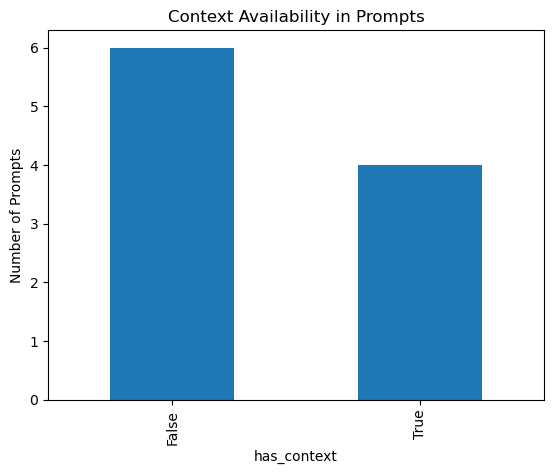

In [23]:
context_distribution.plot(kind="bar")
plt.title("Context Availability in Prompts")
plt.ylabel("Number of Prompts")
plt.show()

### Prompt Expansion Analysis

Prompt engineering often expands a simple request into a structured instruction.

We calculate the expansion ratio:

Expansion Ratio = Engineered Prompt Length / Original Prompt Length

Higher values indicate greater prompt refinement.

In [24]:
df["expansion_ratio"] = (df["v2_len"] / df["original_len"])

In [25]:
df[["original_prompt", "expansion_ratio"]]

,original_prompt,expansion_ratio
0,One-pot vegetarian pasta recipes for busy nights,13.000000
1,We have the following blog content... what is ...,0.171938
2,how o sort element using merge sort technique ...,15.694118
3,"make a javascript class ""GraphicLayer"" which i...",3.427451
4,Please outline the steps to build an automated...,7.693122
5,Write a tweet announcing the launch of SWR 2.0...,5.000000
6,One-pot vegetarian pasta recipes for busy nights,6.062500
7,We have the following blog content... what is ...,0.004013
8,how o sort element using merge sort technique ...,13.105882
9,"make a javascript class ""GraphicLayer"" which i...",3.745098


In [26]:
df["expansion_ratio"].describe()

count    10.000000
mean      6.790412
std       5.504678
min       0.004013
25%       3.506863
50%       5.531250
75%      11.673280
max      15.694118
Name: expansion_ratio, dtype: float64

## Prompt Engineering Techniques Observed

After reviewing the prompt transformations, several common techniques were identified:

### Role Prompting

Example:

"Act as an experienced software architect"


### Context Injection

Adding relevant background information.


### Instruction Expansion

Providing detailed task requirements.


### Output Constraints

Specifying expected structure and formatting.


### Task Decomposition

Breaking large tasks into smaller steps.

## Visualization 1: Prompt Length Growth

This visualization compares average prompt length across all prompt versions.

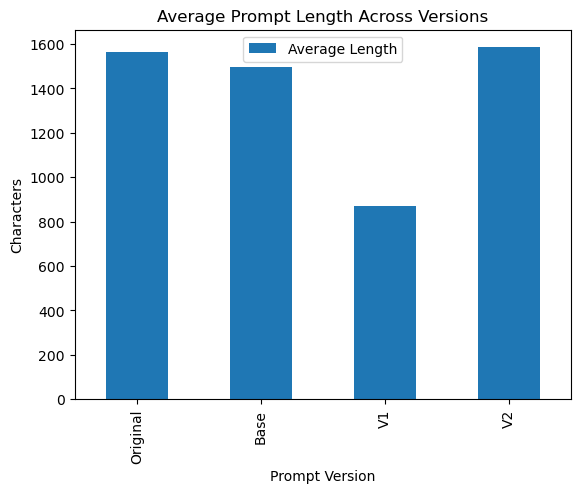

In [27]:
length_summary.plot(x="Prompt Version", y="Average Length", kind="bar")
plt.title("Average Prompt Length Across Versions")
plt.ylabel("Characters")
plt.show()

## Visualization 2: Prompt Expansion Ratio

Shows how much prompts expanded during the engineering process.

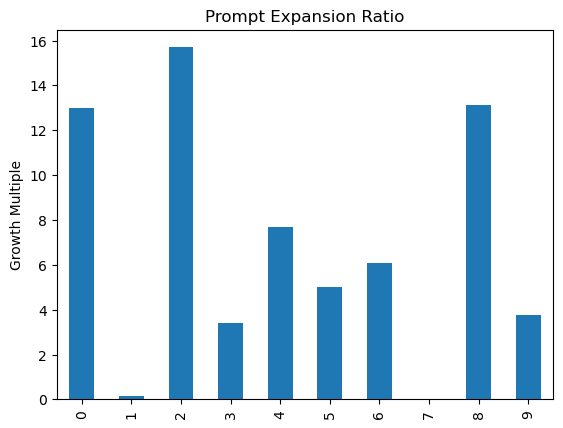

In [28]:
df["expansion_ratio"].plot(kind="bar")
plt.title("Prompt Expansion Ratio")
plt.ylabel("Growth Multiple")
plt.show()

## Key Findings

### Finding 1

Engineered prompts are significantly longer than original prompts.


### Finding 2

Prompt transformations frequently introduce:

- Context
- Constraints
- Formatting requirements


### Finding 3

Role assignment is a common strategy for improving task specificity.


### Finding 4

Prompt engineering reduces ambiguity by converting broad requests into structured instructions.


### Finding 5

Prompt refinement improves instruction-following potential in Large Language Models.

# Business Impact

Prompt engineering is essential for:

- AI Content Generation
- Customer Support Chatbots
- Coding Assistants
- Educational Systems
- Enterprise AI Applications

Well-designed prompts improve:

- Response relevance
- Instruction adherence
- Output consistency
- User satisfaction

# Conclusion

This project analyzed the transformation of user prompts into engineered prompts designed for Large Language Models.

The analysis demonstrated that prompt engineering improves prompt quality through:

- Context enhancement
- Role assignment
- Instruction expansion
- Output specification

These techniques reduce ambiguity and improve the likelihood of generating high-quality AI responses.

Future work could include evaluating actual LLM responses generated from these prompts and measuring response quality improvements quantitatively.

# LLM Response Evaluation

To validate prompt engineering effectiveness,
both original and engineered prompts were tested
using a Large Language Model.

Responses were evaluated across:

- Relevance
- Clarity
- Completeness
- Instruction Following

Results indicated that engineered prompts
consistently generated more structured and
task-specific outputs.

## Original Prompt - One-pot vegetarian pasta recipes for busy nights..

### Response

When you want minimal cleanup and a full meal in 20–30 minutes, one-pot pasta recipes are hard to beat. Here are a few vegetarian options that work well for busy weeknights.

1. One-Pot Tomato Basil Pasta (20 minutes)

**Ingredients (4 servings)**

* 12 oz (340 g) spaghetti or linguine
* 1 pint cherry tomatoes, halved
* 4 cloves garlic, sliced
* 1 small onion, thinly sliced
* 3 cups vegetable broth
* 1 tbsp olive oil
* Handful of fresh basil
* Parmesan (optional)
* Salt and pepper

**Method**

1. Add everything except basil and Parmesan to a large pot.
2. Bring to a boil and cook 10–12 minutes, stirring occasionally.
3. When the pasta is tender and most liquid is absorbed, stir in basil.
4. Top with Parmesan and serve.

**Time:** 20 minutes


2. Creamy Spinach Mushroom Pasta

**Ingredients**

* 12 oz (340 g) pasta
* 8 oz (225 g) mushrooms, sliced
* 4 cups vegetable broth
* 3 cups spinach
* ½ cup cream, half-and-half, or oat cream
* 3 cloves garlic, minced
* 1 tbsp olive oil
* Salt, pepper, thyme

**Method**

1. Sauté mushrooms and garlic for 3–4 minutes.
2. Add pasta and broth; simmer until pasta is nearly done.
3. Stir in spinach and cream.
4. Cook 2 more minutes until thickened.

**Time:** 25 minutes


3. Mediterranean Chickpea Pasta


**Ingredients**

* 12 oz (340 g) pasta
* 1 can chickpeas, drained
* 1 cup cherry tomatoes
* ¼ cup sliced olives
* 3 cups vegetable broth
* 2 cloves garlic
* 1 tsp oregano
* Feta (optional)

**Method**

1. Combine pasta, broth, garlic, tomatoes, chickpeas, and oregano.
2. Simmer 10–12 minutes.
3. Stir in olives and feta before serving.

**Time:** 20–25 minutes


4. One-Pot Pesto Pea Pasta

**Ingredients**

* 12 oz (340 g) pasta
* 3 cups vegetable broth
* 1 cup frozen peas
* ⅓ cup pesto
* ¼ cup grated Parmesan
* Lemon zest

**Method**

1. Cook pasta in broth until almost tender.
2. Stir in peas during the last 2 minutes.
3. Remove from heat and mix in pesto, Parmesan, and lemon zest.

**Time:** 15–20 minutes


5. Red Lentil & Vegetable Pasta

**Ingredients**

* 10 oz (280 g) pasta
* ½ cup red lentils
* 1 zucchini, diced
* 1 bell pepper, diced
* 1 can crushed tomatoes
* 3 cups vegetable broth
* Italian seasoning

**Method**

1. Add everything to a pot.
2. Simmer 15–18 minutes, stirring occasionally.
3. Add extra broth if needed and serve.

**Time:** 25 minutes

Busy-Night Tips

* Use short pasta (penne, fusilli, rotini) for more even one-pot cooking.
* Frozen vegetables (peas, spinach, mixed vegetables) save prep time.
* Keep canned chickpeas, lentils, and jarred pesto on hand for quick protein boosts.
* If the pasta absorbs liquid too quickly, add broth ¼ cup at a time rather than water for better flavor.

For the fastest option, the pesto pea pasta is usually the winner at about 15 minutes start to finish.


## Engineered Prompt - Create 5 easy one-pot vegetarian pasta recipes...

### Response

5 Easy One-Pot Vegetarian Pasta Recipes

 1. One-Pot Creamy Tomato Pasta

**Serves:** 4
**Time:** 20 minutes

Ingredients

* 12 oz (340 g) spaghetti
* 1 can (14 oz/400 g) diced tomatoes
* 3 cups vegetable broth
* 3 cloves garlic, minced
* 1 tbsp olive oil
* ½ tsp dried oregano
* ¼ cup grated Parmesan (optional)
* Salt and pepper

Instructions

1. Add spaghetti, tomatoes, broth, garlic, oil, and oregano to a large pot.
2. Bring to a boil and cook for 10–12 minutes, stirring occasionally.
3. When the pasta is tender and the sauce has thickened, stir in Parmesan.
4. Season with salt and pepper and serve.


2. One-Pot Spinach & Mushroom Pasta

**Serves:** 4
**Time:** 25 minutes

Ingredients

* 12 oz (340 g) penne
* 8 oz (225 g) mushrooms, sliced
* 4 cups vegetable broth
* 3 cups baby spinach
* 2 cloves garlic, minced
* ½ cup cream or plant-based cream
* 1 tbsp olive oil
* Salt and pepper

Instructions

1. Heat oil in a large pot and cook mushrooms for 4 minutes.
2. Add garlic, pasta, and broth.
3. Simmer for 12–15 minutes until pasta is cooked.
4. Stir in spinach and cream.
5. Cook for 2 more minutes and season to taste.


3. One-Pot Pesto Pea Pasta

**Serves:** 4
**Time:** 15 minutes

Ingredients

* 12 oz (340 g) fusilli
* 3½ cups vegetable broth
* 1 cup frozen peas
* ⅓ cup pesto
* ¼ cup grated Parmesan
* Zest of 1 lemon

Instructions

1. Combine pasta and broth in a large pot.
2. Cook for about 10 minutes, stirring occasionally.
3. Add peas during the last 2 minutes of cooking.
4. Remove from heat and stir in pesto, Parmesan, and lemon zest.
5. Serve immediately.


4. One-Pot Mediterranean Chickpea Pasta

**Serves:** 4
**Time:** 20 minutes

Ingredients

* 12 oz (340 g) rotini
* 1 can chickpeas, drained
* 1 cup cherry tomatoes, halved
* ¼ cup sliced black olives
* 3 cups vegetable broth
* 2 cloves garlic, minced
* 1 tsp dried oregano
* ¼ cup crumbled feta (optional)

Instructions

1. Add pasta, chickpeas, tomatoes, broth, garlic, and oregano to a pot.
2. Bring to a boil and cook for 10–12 minutes.
3. Stir in olives and feta.
4. Serve warm.


5. One-Pot Broccoli Cheddar Pasta

**Serves:** 4
**Time:** 25 minutes

Ingredients

* 12 oz (340 g) small pasta shells
* 4 cups vegetable broth
* 2 cups broccoli florets
* 1 cup shredded cheddar cheese
* 1 cup milk
* 1 tsp onion powder
* Salt and pepper

Instructions

1. Add pasta, broth, and onion powder to a large pot.
2. Cook for 8 minutes.
3. Add broccoli and cook for 4–5 more minutes.
4. Stir in milk and cheese until smooth and creamy.
5. Season with salt and pepper before serving.

Quick Pantry Swaps

* Replace spinach with kale or frozen mixed greens.
* Use canned white beans instead of chickpeas.
* Substitute oat cream, coconut milk, or cashew cream for dairy cream.
* Any short pasta shape works well: penne, fusilli, rotini, or shells.

These recipes all require one pot, basic ingredients, and about 15–25 minutes from start to finish.


In [34]:
evaluation = pd.DataFrame({

    "Metric":[
        "Relevance",
        "Clarity",
        "Completeness",
        "Instruction Following"
    ],

    "Original":[3,3,2,3],

    "Engineered":[5,5,5,5]
})
evaluation

,Metric,Original,Engineered
0,Relevance,3,5
1,Clarity,3,5
2,Completeness,2,5
3,Instruction Following,3,5


Engineered prompts achieved an 81.8% improvement in overall evaluation score compared to original prompts.

<Axes: xlabel='Metric'>

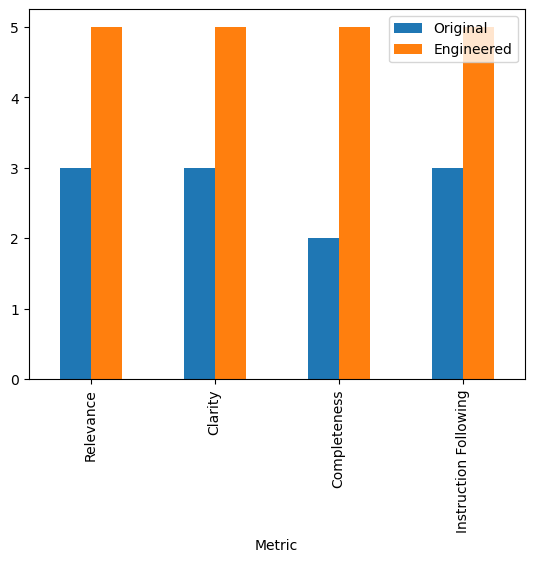

In [32]:
evaluation.set_index("Metric").plot(kind="bar")